# Logistic Regression on Win Column

This notebook will build and train a logistic regression model to classify each match into win/loss. We will do this on three versions of our dataset. One will be trained on the usual dataset, one on just the odds, and one on the dataset without odds. The reason we will do this is to investigate the effect that the odds columns have on prediction. Since these are win probabilities given by bookmakers, they are a very good prediction of who will win the match. They already include much of the information given by the other columns in the dataset, since this is publicly available information and bookmaker models would have taken exactly this information into account when producing the odds. Hence, it may be the case that odds are extremely good predictor of win/loss, and all other columns are redundant. On the other hand, it may be the case that the other columns are able to give a good prediction of the gap between the true win probability and the bookmaker-predicted win probability. This is what we will explore with the different datasets.

## 1. Preparing the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import shuffle_data_df, train_test_split_df, standardise

sns.set_style("whitegrid")

df_full = pd.read_csv("../Data/full_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")


df_full.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,18,1,0,...,0,0,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,18,1,0,...,0,1,1,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,18,1,1,...,0,1,1,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,18,1,1,...,0,1,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,18,1,1,...,0,1,0,0,1,0,0,0,0,0


In [2]:
# Shuffle data
df_full_shuff = shuffle_data_df(df_full)
df_odds_shuff = shuffle_data_df(df_odds)
df_nodds_shuff = shuffle_data_df(df_nodds)

df_full_shuff.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,1.440,5750,5,2.75,1,35,1,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,1.550,6620,3,2.60,1,32,1,1,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1.170,1120,47,5.00,1,38,0,0,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,1.002,603,87,34.00,1,28,1,1,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,1.360,2195,15,3.20,1,22,1,0,...,0,1,0,0,0,0,0,0,0,1


In [3]:
# Train test split
df_full_train, df_full_test = train_test_split_df(df_full_shuff, 0.8)
df_odds_train, df_odds_test = train_test_split_df(df_odds_shuff, 0.8)
df_nodds_train, df_nodds_test = train_test_split_df(df_nodds_shuff, 0.8)

## 2. Logistic Regression Model / Functions

Here, we will define all of the functions we require to produce our logistic regression model.

In [4]:
def stable_sigmoid(x):
    

    return np.where(x >= 0, 1. / ( 1. + np.exp(-x)), np.exp(x) / ( 1. + np.exp(x) ))

In [5]:
def binary_cross_entrop(y_true, probs, eps=1e-7):

    """
        Computes the binary cross entrop given a vector of true binary labels and a vector of
        probability predictions
    """

    probs = np.clip(probs, eps, 1-eps)
    return - np.mean(y_true * np.log(probs) + (1 - y_true) * (np.log(1 - probs)))

In [6]:
def bce_grad(X, y_true, probs):

    """
        Computes the gradient of the binary cross-entropy with respect to theta.
    """

    return (1 / X.shape[0]) * X.T @ (probs - y_true)

In [ ]:
def gradient_descent(X, y, lr=1e-3, iter=10000, thresh=1e-7):

    """
        This is a gradient descent training loop for logistic regression.
    """

    # Initialise coefficients, probabilities vector and loss array
    theta = np.ones((X.shape[1], 1))
    losses = []

    # Begin descent loop
    for i in range(iter):

        # Calculate probabilities
        z = (X @ theta).reshape(-1, 1)
        probs = stable_sigmoid(z)

        # Calculate binary cross entropy and gradient
        loss = binary_cross_entrop(y, probs)
        losses.append(float(loss))
        grad = bce_grad(X, y, probs)

        # Print loss every 1000th iteration number
        if (i+1) % 1000 == 0:
            print(f"Iteration {i+1}")
            print("Loss", loss)

        # Update theta
        theta_new = theta - lr * grad

        # Check for early convergence
        if np.linalg.norm(grad) <= thresh:
            print(fr"We have reached early convergence on iteration {i+1}.")
            return theta_new

        # Update theta
        theta = theta_new

    print(fr"Reached max iterations.")
    return theta, losses

In [8]:
def hard_thresh(probs):

    """
        Calculate the 1/0 prediction from the probability scores
    """

    return np.where(probs >= 0.5, 1, 0)

In [9]:
def accuracy(y_true, y_hat):

    """
        Calculates the accuracy of the model. y_true are the true labels and y_hat are the hard
        thresholded probabilities.
    """

    return np.mean(y_true == y_hat) * 100

## 3. Odds Dataset

We begin with a dataset containing only the odds columns, and evaluate how well it predicts Djokovic's win probability.

In [10]:
df_odds_train.head()

,dj_odds,opp_odds,dj_win
1057,1.440,2.75,1
938,1.550,2.60,1
1228,1.170,5.00,1
683,1.002,34.00,1
282,1.360,3.20,1


In [11]:
# Separating target from predictors
y_train, y_test = df_odds_train['dj_win'].to_numpy().reshape(-1, 1), df_odds_test['dj_win'].to_numpy().reshape(-1, 1)
X_train, X_test = df_odds_train[['dj_odds', 'opp_odds']].to_numpy(), df_odds_test[['dj_odds', 'opp_odds']].to_numpy()

In [12]:
# Standardise and augment prediction matrix
X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train)

X_train_sa = np.concatenate([np.ones((X_train_std.shape[0], 1)), X_train_std], axis=1)
X_test_sa = np.concatenate([np.ones((X_test_std.shape[0], 1)), X_test_std], axis=1)

Now that our data is fully separated, standardised, and augmented, we can train our model.

In [13]:
# Train the model
theta, losses = gradient_descent(X_train_sa, y_train, iter=300000)

Iteration 200
Loss 0.5625028181753648
Iteration 400
Loss 0.5535272264329986
Iteration 600
Loss 0.5450122507094165
Iteration 800
Loss 0.5369213019611656
Iteration 1000
Loss 0.529221389449293
Iteration 1200
Loss 0.5218827749372907
Iteration 1400
Loss 0.5148786592320563
Iteration 1600
Loss 0.5081848988417484
Iteration 1800
Loss 0.5017797504404817
Iteration 2000
Loss 0.4956436408348532
Iteration 2200
Loss 0.4897589601943584
Iteration 2400
Loss 0.48410987641588565
Iteration 2600
Loss 0.4786821686260141
Iteration 2800
Loss 0.47346307797171405
Iteration 3000
Loss 0.46844117400114627
Iteration 3200
Loss 0.463606235084103
Iteration 3400
Loss 0.4589491414599078
Iteration 3600
Loss 0.4544617796231722
Iteration 3800
Loss 0.45013695685824073
Iteration 4000
Loss 0.4459683248041214
Iteration 4200
Loss 0.4419503109646827
Iteration 4400
Loss 0.43807805706430825
Iteration 4600
Loss 0.4343473630768781
Iteration 4800
Loss 0.43075463561693567
Iteration 5000
Loss 0.42729683917123645
Iteration 5200
Loss 0.42

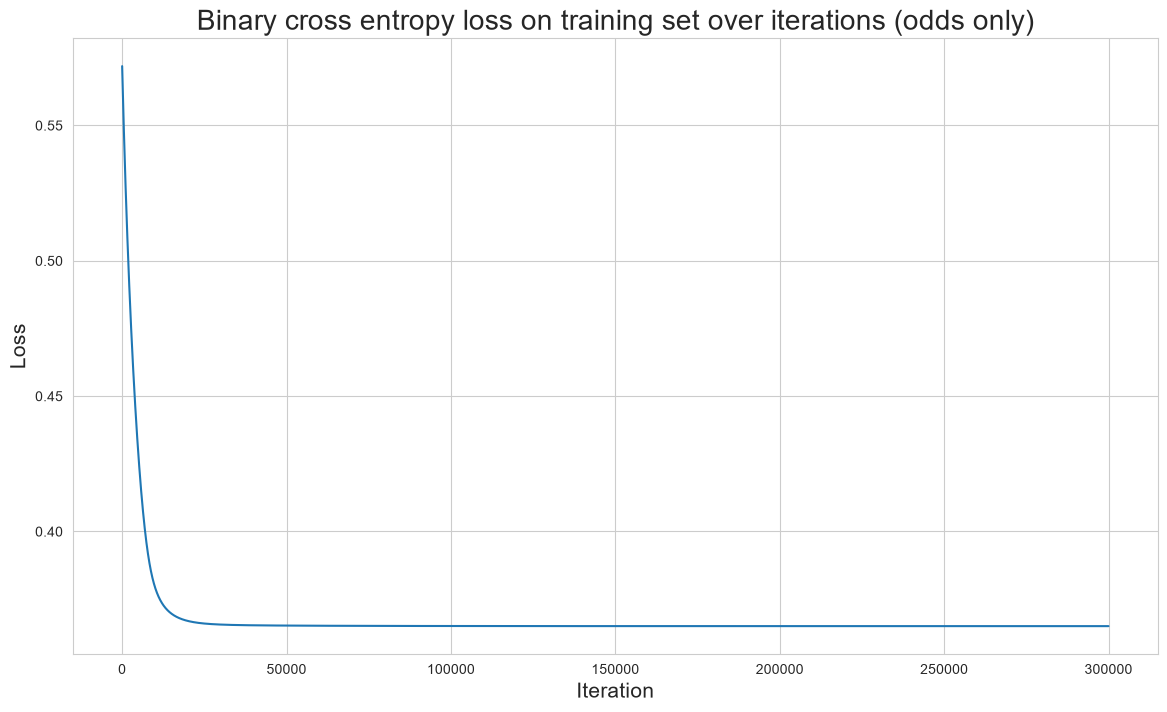

In [14]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (odds only)", fontsize=20)
plt.show()


In [15]:
# Test set loss and accuracy
z_test = X_test_sa @ theta
probs_test = stable_sigmoid(z_test)
bce = binary_cross_entrop(y_test, probs_test)
y_hat = hard_thresh(probs_test)
acc = accuracy(y_test, y_hat)
print("Odds Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Odds Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Test Loss: 0.3599
Accuracy: 84.00%


In [16]:
majority_baseline = df_full['dj_win'].mean()   # accuracy of "always predict the majority class"
print(majority_baseline)

0.8398718975180144


## 4. No Odds Dataset

We will now train a logistic regression model on the same train / test split of the dataset using all columns apart from the odds columns. This will be informative to see whether the bookmaker predictions will be better indicators of win/loss than what we can predict using our chosen variables.

In [17]:
df_nodds_train.head()

,dj_pts,dj_rank,opp_pts,opp_rank,dj_win,age,is_outdoor,is_five_sets,5SMA,ATP250,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,5750,5,1,35,1,0,0.8,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,6620,3,1,32,1,1,1.0,0,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1120,47,1,38,0,0,0.8,1,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,603,87,1,28,1,1,1.0,0,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,2195,15,1,22,1,0,0.8,0,...,0,1,0,0,0,0,0,0,0,1


In [18]:
# Separate target from predictors
X_train, X_test = df_nodds_train.drop(columns='dj_win'), df_nodds_test.drop(columns='dj_win')

In [19]:
# Now convert to numpy arrays, standardise, and augment
X_nodds_train_std = standardise(X_train.to_numpy())
X_nodds_test_std = standardise(X_test.to_numpy(), scaler=X_train.to_numpy())

X_nodds_train_sa = np.concatenate([np.ones((X_nodds_train_std.shape[0], 1)), X_nodds_train_std], axis=1)
X_nodds_test_sa = np.concatenate([np.ones((X_nodds_test_std.shape[0], 1)), X_nodds_test_std], axis=1)

Now our data is fully prepared for us to run our logistic regression.

In [20]:
theta_nodds, losses_nodds = gradient_descent(X_nodds_train_sa, y_train, iter=300000)

Iteration 200
Loss 0.9446408783331823
Iteration 400
Loss 0.9100020515645421
Iteration 600
Loss 0.8778381371627824
Iteration 800
Loss 0.8479952306848574
Iteration 1000
Loss 0.8203216099635974
Iteration 1200
Loss 0.7946691601728543
Iteration 1400
Loss 0.7708945652848853
Iteration 1600
Loss 0.74886027713758
Iteration 1800
Loss 0.7284352663695326
Iteration 2000
Loss 0.7094955602017715
Iteration 2200
Loss 0.6919245776472775
Iteration 2400
Loss 0.6756132799969947
Iteration 2600
Loss 0.6604601607827223
Iteration 2800
Loss 0.6463711033800095
Iteration 3000
Loss 0.6332591355894371
Iteration 3200
Loss 0.6210441092733723
Iteration 3400
Loss 0.6096523301434856
Iteration 3600
Loss 0.5990161588665908
Iteration 3800
Loss 0.5890736004385289
Iteration 4000
Loss 0.5797678947348556
Iteration 4200
Loss 0.5710471175638716
Iteration 4400
Loss 0.5628637985516397
Iteration 4600
Loss 0.5551745598030908
Iteration 4800
Loss 0.5479397774653252
Iteration 5000
Loss 0.5411232669916793
Iteration 5200
Loss 0.534691991

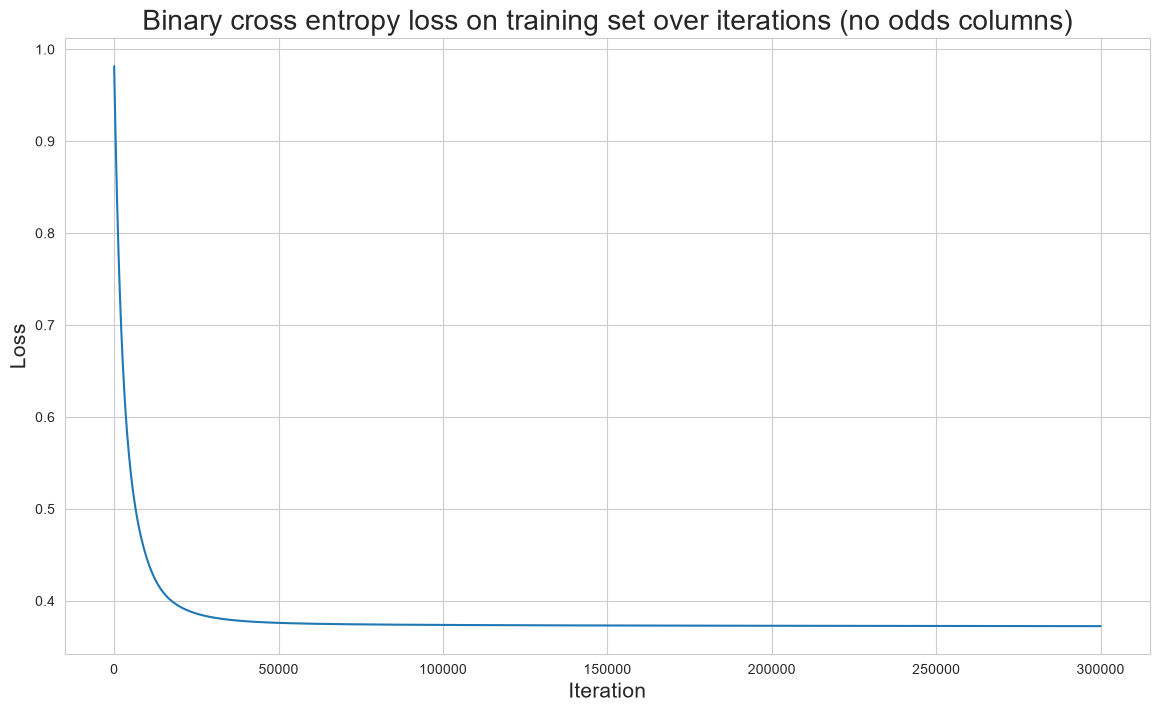

In [21]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses_nodds)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (no odds columns)", fontsize=20)
plt.show()


In [22]:
# Test set loss and accuracy
z_test_nodds = X_nodds_test_sa @ theta_nodds
probs_nodds_test = stable_sigmoid(z_test_nodds)
bce = binary_cross_entrop(y_test, probs_nodds_test)
y_hat_nodds = hard_thresh(probs_nodds_test)
acc = accuracy(y_test, y_hat_nodds)
print("Non-Odds Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Non-Odds Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Test Loss: 0.3954
Accuracy: 83.60%


As we can see, the binary cross entropy on both the training set and the test set is worse for the model with no odds columns than the model with just odds columns. This indicates that the odds columns on their own are a better predictor of the win probabilities than all of the other columns all together. Interestingly, the accuracy is the same. This happens because we use hard thresholding. The no odds model is less confident in it's probability assigments than the odds model, meaning it's assigned probabilities are closer to $0.5$ than the odds model, although the hard-thresholded results are all the same. This leads to a greater binary cross entropy than for the odds model, because less confidence (less extreme probability assigments) means the logarithm terms become larger in the binary cross entropy.

## 5. Entire Dataset

We will now investigate the performance of logistic regression on the entire dataset. This will show us whether the columns we have chosen apart from odds can help explain some of the further noise (randomness) in matches that the bookmaker odds cannot predict.

In [23]:
# Separate target from predictors
X_train, X_test = df_full_train.drop(columns='dj_win'), df_full_test.drop(columns='dj_win')

In [24]:
# Now convert to numpy arrays, standardise and augment
X_full_train_std = standardise(X_train.to_numpy())
X_full_test_std = standardise(X_test.to_numpy(), scaler=X_train.to_numpy())

X_full_train_sa = np.concatenate([np.ones((X_full_train_std.shape[0], 1)), X_full_train_std], axis=1)
X_full_test_sa = np.concatenate([np.ones((X_full_test_std.shape[0], 1)), X_full_test_std], axis=1)

In [25]:
theta_full, losses_full = gradient_descent(X_full_train_sa, y_train, iter=300000)

Iteration 200
Loss 1.107354327294765
Iteration 400
Loss 1.0634134437153133
Iteration 600
Loss 1.0222161869884971
Iteration 800
Loss 0.9836332392453285
Iteration 1000
Loss 0.9475321278430231
Iteration 1200
Loss 0.9137788145383012
Iteration 1400
Loss 0.8822391666827192
Iteration 1600
Loss 0.8527803044293361
Iteration 1800
Loss 0.825271816144944
Iteration 2000
Loss 0.7995868289059344
Iteration 2200
Loss 0.7756029174784522
Iteration 2400
Loss 0.7532028369975784
Iteration 2600
Loss 0.7322750718711138
Iteration 2800
Loss 0.712714203889793
Iteration 3000
Loss 0.6944211129698503
Iteration 3200
Loss 0.6773030319480311
Iteration 3400
Loss 0.6612734813085015
Iteration 3600
Loss 0.646252110760993
Iteration 3800
Loss 0.6321644729985654
Iteration 4000
Loss 0.6189417517189623
Iteration 4200
Loss 0.6065204619574972
Iteration 4400
Loss 0.5948421365915335
Iteration 4600
Loss 0.5838530089555463
Iteration 4800
Loss 0.5735036981000379
Iteration 5000
Loss 0.5637489004709688
Iteration 5200
Loss 0.55454708974

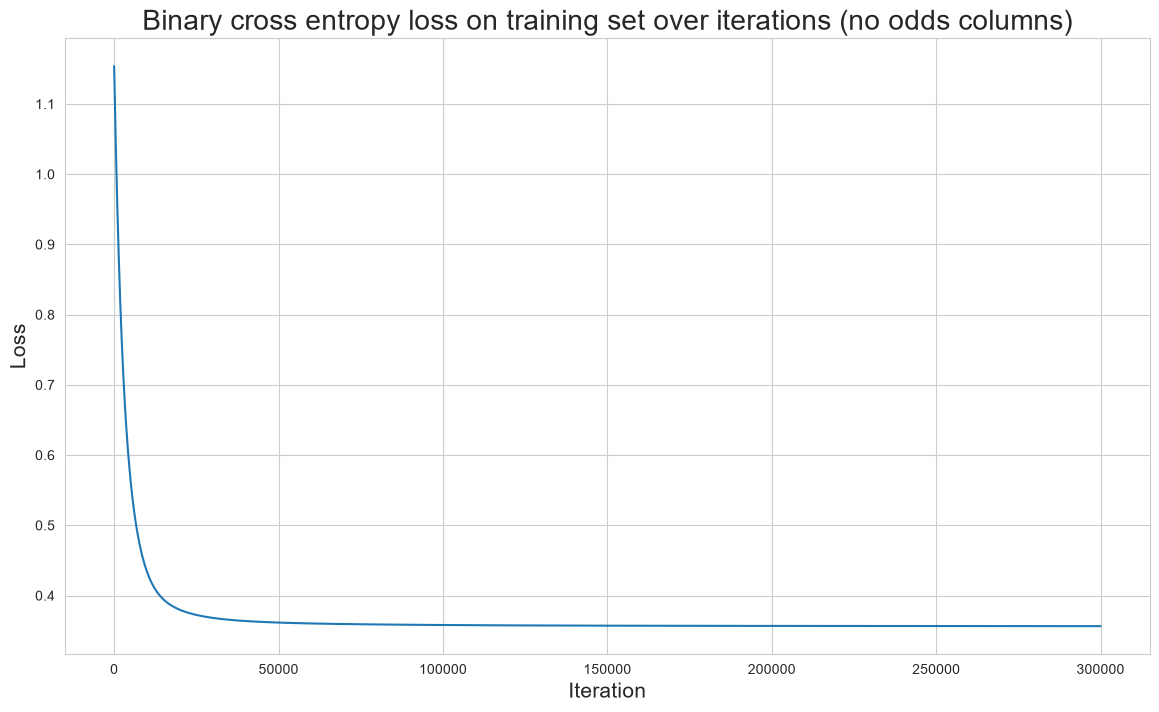

In [ ]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses_full)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (full dataset)", fontsize=20)
plt.show()


In [27]:
# Test set loss and accuracy
z_test_full = X_full_test_sa @ theta_full
probs_full_test = stable_sigmoid(z_test_full)
bce = binary_cross_entrop(y_test, probs_full_test)
y_hat_full = hard_thresh(probs_full_test)
acc = accuracy(y_test, y_hat_full)
print("Full Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Full Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Test Loss: 0.3713
Accuracy: 84.40%


## 6. Discussion

#### Results Summary

| Model (dataset)        | Train BCE | Test BCE | Test accuracy |
|------------------------|-----------|----------|---------------|
| Odds only              | 0.3650    | 0.3599   | 84.0%         |
| No odds                | 0.3725    | 0.3954   | 83.60%        |
| Full (all features)    | 0.3564    | 0.3713   | 84.40%        |

*Base-rate baseline (predict win rate ≈0.84 for every match): BCE ≈ 0.44, accuracy ≈ 84.0%.*

We can see from the results summary that the additional features outside of the odds column do not add any significant additional signal that the odds don't already provide. The model trained on the no odds data has a slightly worse training loss, test loss, and accuracy. Although the changes in these metrics are not substantial, there is clearly worse performance in the model trained on the no odds dataset, relative to the model trained on only odds.

The full dataset achieves a slightly better training loss and accuracy than the odds only data, but produces a worse test loss. This can happen if the additional features slightly nudge some borderline probabilities to the correct side of $0.5$, improving the accuracy, while simultaneously the additional features push some upsets further towards $1.0$, making the model have more confidently wrong predictions, which negatively affects the binary cross entropy.

Overall, there is no substantial improvement in model performance through the addition of our features. Some different and more informative features need to be engineered in order to beat the signal that the odds produce.